# PCA (Análisis de Componentes Principales)
Este cuaderno muestra cómo aplicar PCA para reducir la dimensionalidad del conjunto de datos.

In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=5, n_informative=3,
                           n_redundant=0, n_classes=3, random_state=42)
df = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(5)])
df['Target'] = y
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,-0.275052,1.824839,0.548047,-2.301921,1.505511,0
1,-0.651836,-1.237444,-0.517609,0.047399,-3.062881,2
2,1.502357,-2.375537,-1.034946,0.074095,-1.947204,2
3,2.060748,1.190509,1.215335,1.755341,-0.580419,2
4,-0.066080,-2.050219,2.862383,-1.211016,-1.887037,2


### Escalado
Escalamos las variables para que todas tengan media 0 y varianza 1.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('Target', axis=1))

### Aplicar PCA
Reducimos las 5 variables a 2 componentes principales.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Target'] = y
df_pca.head()

,PC1,PC2,Target
0,0.560611,-0.085261,0
1,0.752853,-0.897050,2
2,-1.006341,-1.447630,2
3,0.532863,0.373256,2
4,0.320450,0.303775,2


### Varianza explicada
Veamos cuánta información conserva cada componente.

In [15]:
explained = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {explained[0]:.2f}')
print(f'Varianza explicada por PC2: {explained[1]:.2f}')

Varianza explicada por PC1: 0.24
Varianza explicada por PC2: 0.22


### Visualización de los datos proyectados

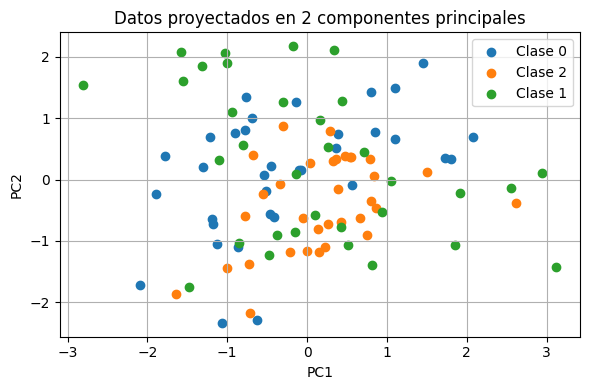

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
for label in df_pca['Target'].unique():
    subset = df_pca[df_pca['Target'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Clase {label}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Datos proyectados en 2 componentes principales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**¿Qué conseguimos con PCA?**
Reducimos de 5 dimensiones a 2 manteniendo la mayor parte de la información. Esto ayuda a visualizar, reducir ruido o mejorar rendimiento si hay muchas variables correlacionadas.

In [17]:
# PCA con 3 componentes y varianza explicada
from sklearn.decomposition import PCA

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)               # X_scaled es la matriz numérica ya escalada

print("Varianza explicada por cada PC:", pca3.explained_variance_ratio_)
print("Varianza acumulada:", pca3.explained_variance_ratio_.sum())

Varianza explicada por cada PC: [0.24167678 0.21831955 0.20528468]
Varianza acumulada: 0.6652810107410814


In [18]:
# PCA con 4 componentes
pca4 = PCA(n_components=4)
pca4.fit(X_scaled)

print("Varianza explicada por cada PC:", pca4.explained_variance_ratio_)
print("Varianza acumulada:", pca4.explained_variance_ratio_.sum())

Varianza explicada por cada PC: [0.24167678 0.21831955 0.20528468 0.17820367]
Varianza acumulada: 0.8434846764103359
